## Luật số lớn và Định lý giới hạn trung tâm 

1. **Multivariate LLN:** Quan sát sự hội tụ của trung bình mẫu ($\bar{x}$) về trung bình quần thể ($\mu$) của tất cả các đặc trưng hóa học cùng lúc.
2. **CLT Comparison:** So sánh cách phân phối trung bình mẫu của các biến khác nhau tiến về phân phối chuẩn.

## Preprocessing

Các biến như `total sulfur dioxide` và `chlorides` có thang đo rất khác nhau, chúng ta nên chuẩn hóa dữ liệu hoặc vẽ tỉ lệ lỗi (%) để so sánh sự hội tụ

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys
import os

sys.path.append(os.path.abspath("..")) 
from source.utils import mean, variance, standard_deviation, covariance, correlation

df = pd.read_csv('../data/WineQT.csv', sep=',')
features = df.drop(columns=['quality', 'Id'])
var_list = features.columns.tolist()

pop_means = {col: mean(features[col]) for col in features.columns}
pop_stds = {col: standard_deviation(features[col], is_population=True) for col in features.columns}

results_df = pd.DataFrame({
    'Variable': features.columns,
    'Population Mean': [pop_means[col] for col in features.columns],
    'Population Std Dev': [pop_stds[col] for col in features.columns]
})

print("Trung bình quần thể của các biến:")
print(results_df[['Variable', 'Population Mean']])

print("\nĐộ lệch chuẩn quần thể của các biến:")
print(results_df[['Variable', 'Population Std Dev']])

Trung bình quần thể của các biến:
                Variable  Population Mean
0          fixed acidity         8.311111
1       volatile acidity         0.531339
2            citric acid         0.268364
3         residual sugar         2.532152
4              chlorides         0.086933
5    free sulfur dioxide        15.615486
6   total sulfur dioxide        45.914698
7                density         0.996730
8                     pH         3.311015
9              sulphates         0.657708
10               alcohol        10.442111

Độ lệch chuẩn quần thể của các biến:
                Variable  Population Std Dev
0          fixed acidity            1.746830
1       volatile acidity            0.179555
2            citric acid            0.196600
3         residual sugar            1.355324
4              chlorides            0.047247
5    free sulfur dioxide           10.246001
6   total sulfur dioxide           32.767787
7                density            0.001924
8                  

## Luật số lớn - So sánh tốc độ hội tụ
Chúng ta sẽ tính toán sai số tương đối (Relative Error) giữa $\bar{x}$ và $\mu$ khi $n$ tăng dần:
$$Error = \frac{|\bar{x} - \mu|}{\mu}$$

In [10]:
np.random.seed(42)  
sizes = np.arange(10, 1001, 10)

results_lln = {v: [] for v in features.columns}
for n in sizes:
    idx = np.random.choice(len(features), size=n, replace=False)
    sample = features.iloc[idx]
    for col in features.columns:
        err = abs(mean(sample[col]) - pop_means[col]) / pop_means[col]
        results_lln[col].append(err)

print("LLN simulation completed.")
print(f"Sample size: {sizes[0]} -> {sizes[-1]}")

LLN simulation completed.
Sample size: 10 -> 1000


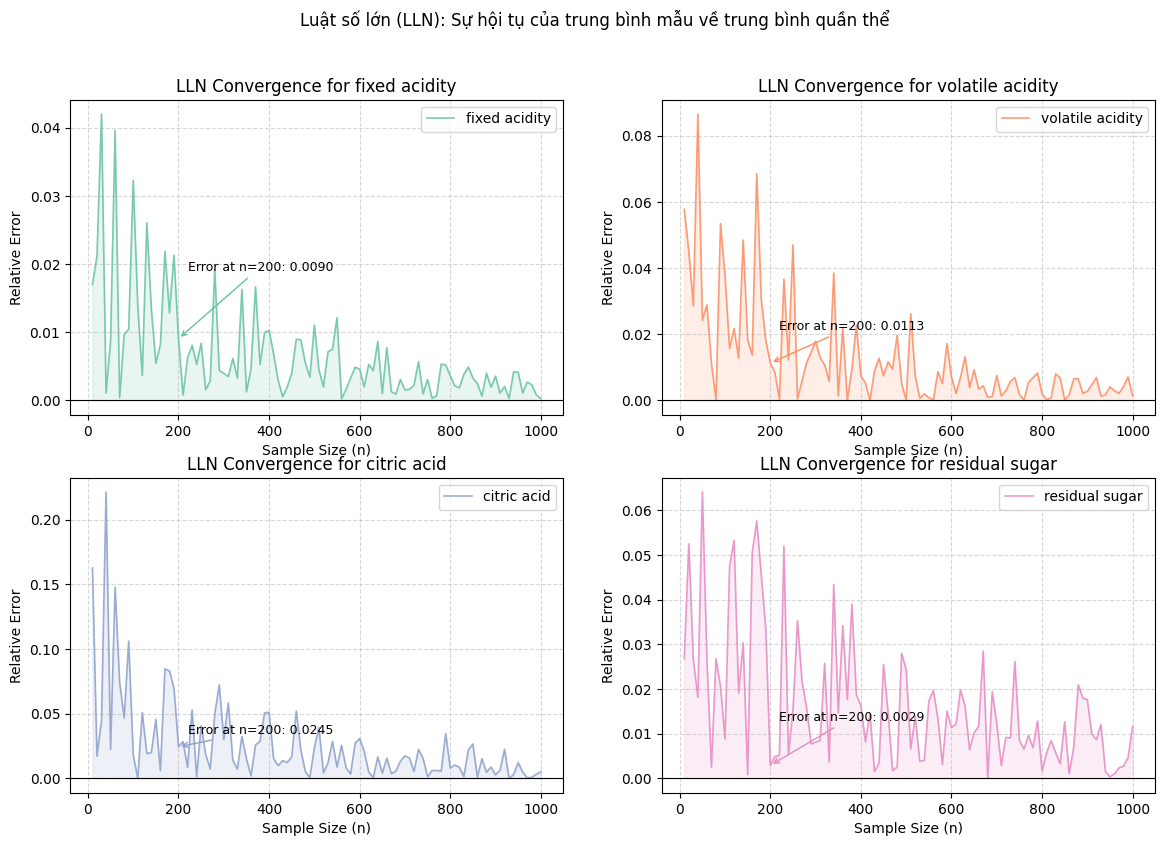

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = sns.color_palette("Set2", len(features.columns))

for ax, col, color in zip(axes, features.columns, colors):
    ax.plot(sizes, results_lln[col], color=color, lw=1.2, alpha=0.85, label=col)
    ax.axhline(0, color='black', lw=0.8)
    ax.fill_between(sizes, results_lln[col], alpha=0.15, color=color)
    ax.set_title(f'LLN Convergence for {col}', fontsize=12)
    ax.set_xlabel('Sample Size (n)', fontsize=10)
    ax.set_ylabel('Relative Error', fontsize=10)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend()

    idx = np.searchsorted(sizes, 200)
    ax.annotate(f'Error at n=200: {results_lln[col][idx]:.4f}', 
                xy=(sizes[idx], results_lln[col][idx]), 
                xytext=(sizes[idx]+20, results_lln[col][idx]+0.01),
                arrowprops=dict(arrowstyle='->', color=color),
                fontsize=9)
    
plt.suptitle("Luật số lớn (LLN): Sự hội tụ của trung bình mẫu về trung bình quần thể")
plt.show()

## Định luật giới hạn trung tâm

In [12]:
np.random.seed(42)
n_size = 50
n_trials = 1000

results_clt = {v: [] for v in features.columns}
for _ in range(n_trials):
    idx = np.random.choice(len(features), size=n_size, replace=True)
    sample = features.iloc[idx]
    for col in features.columns:
        results_clt[col].append(mean(sample[col]))

print(f"CLT: {n_trials} lần lấy mẫu với kích thước n={n_size}.")

for col in features.columns:
    emp_mean = np.mean(results_clt[col])
    emp_std = np.std(results_clt[col])
    theory_std = pop_stds[col] / np.sqrt(n_size)
    print(f"  {col:25s}  μ_emp={emp_mean:.4f}  σ_emp={emp_std:.4f}  σ_theory={theory_std:.4f}")

CLT: 1000 lần lấy mẫu với kích thước n=50.
  fixed acidity              μ_emp=8.3073  σ_emp=0.2495  σ_theory=0.2470
  volatile acidity           μ_emp=0.5342  σ_emp=0.0252  σ_theory=0.0254
  citric acid                μ_emp=0.2665  σ_emp=0.0280  σ_theory=0.0278
  residual sugar             μ_emp=2.5385  σ_emp=0.1925  σ_theory=0.1917
  chlorides                  μ_emp=0.0868  σ_emp=0.0066  σ_theory=0.0067
  free sulfur dioxide        μ_emp=15.5724  σ_emp=1.3974  σ_theory=1.4490
  total sulfur dioxide       μ_emp=45.8914  σ_emp=4.6340  σ_theory=4.6341
  density                    μ_emp=0.9967  σ_emp=0.0003  σ_theory=0.0003
  pH                         μ_emp=3.3115  σ_emp=0.0226  σ_theory=0.0221
  sulphates                  μ_emp=0.6563  σ_emp=0.0233  σ_theory=0.0241
  alcohol                    μ_emp=10.4332  σ_emp=0.1493  σ_theory=0.1530


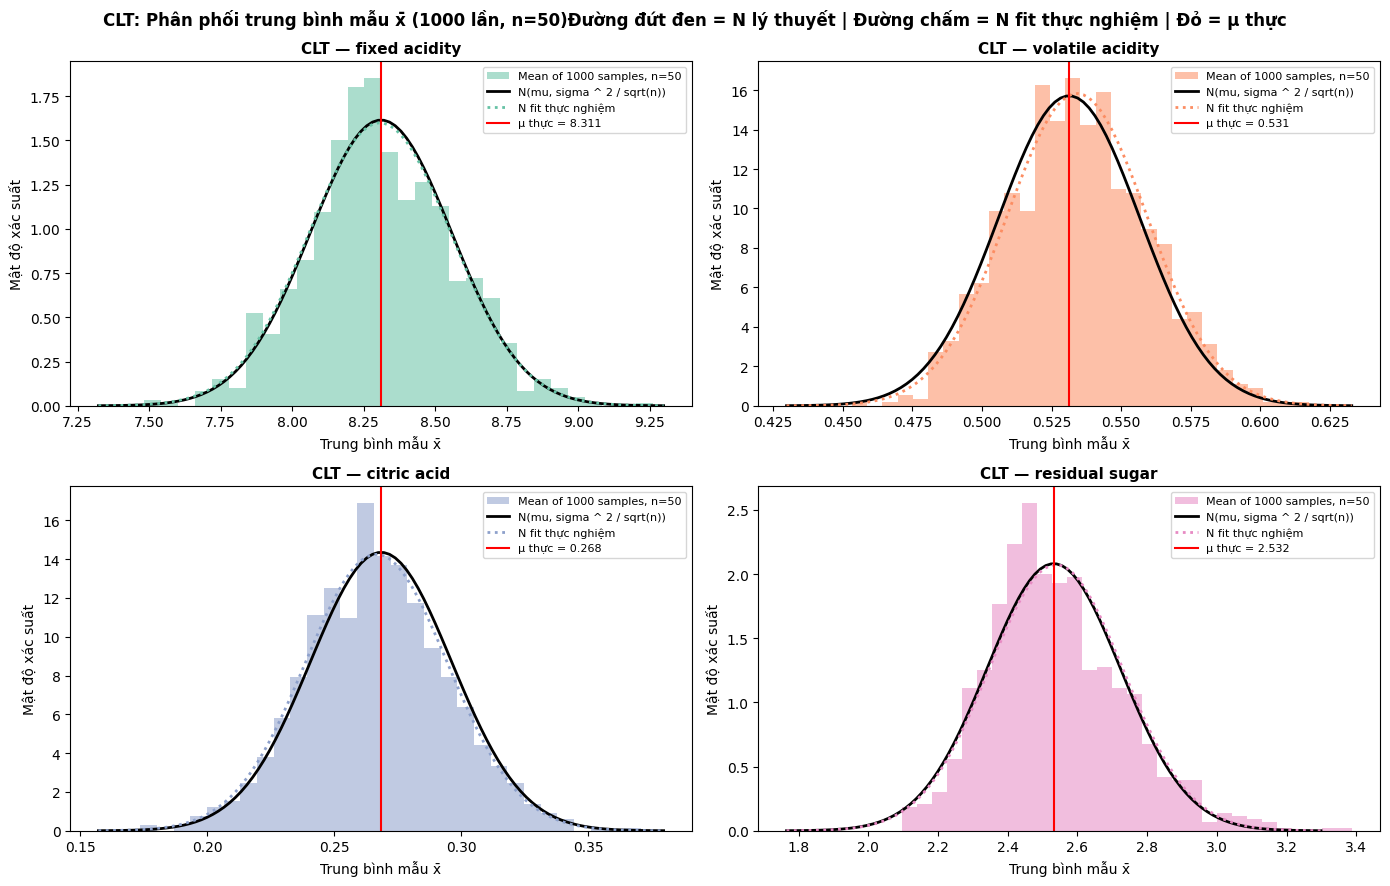

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col, color in zip(axes, features.columns, colors):
    data = results_clt[col]
    mu_col = pop_means[col]
    sigma_col = pop_stds[col] 
    theory_std = sigma_col / np.sqrt(n_size)

    ax.hist(data, bins=30, density=True, color=color, alpha=0.55, label=f'Mean of 1000 samples, n={n_size}')

    x_range = np.linspace(mu_col - 4*theory_std, mu_col + 4*theory_std, 100)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_col, theory_std), color='black', lw=2, label=f'N(mu, sigma ^ 2 / sqrt(n))')

    emp_std = np.std(data)
    ax.plot(x_range, stats.norm.pdf(x_range, np.mean(data), emp_std), color=color, lw=2, ls=":", label="N fit thực nghiệm")

    ax.axvline(mu_col, color="red", lw=1.5, ls="-", label=f"μ thực = {mu_col:.3f}")
    ax.set_xlabel("Trung bình mẫu x̄", fontsize=10)
    ax.set_ylabel("Mật độ xác suất", fontsize=10)
    ax.set_title(f"CLT — {col}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle(f"CLT: Phân phối trung bình mẫu x̄ ({n_trials} lần, n={n_size})"
             "Đường đứt đen = N lý thuyết | Đường chấm = N fit thực nghiệm | Đỏ = μ thực",
             fontsize=12, fontweight="bold")
plt.show()
